# Global Data Science Salary Analysis (2020–2022)

This project analyzes salary data from global data science roles between 2020 and 2022. The objective is to understand how experience level, job title, company size, employment type, remote work, and geographic location influence compensation.

The findings can help organizations benchmark salaries and help professionals understand trends in the global data science job market.

# Business Questions

This project investigates the key factors influencing salaries in data science-related roles and develops a predictive model to estimate annual salaries.

The analysis is guided by the following business questions:

1. How does professional experience influence annual salary?

2. Does company size affect employee compensation?

3. How does work arrangement (On-site, Hybrid, or Remote) influence salary?

4. Which data science roles offer the highest average salaries?

5. How have average salaries changed between 2020 and 2022?

6. Can a machine learning model accurately predict annual salaries using job-related characteristics?

7. Which job characteristics contribute most to salary prediction?


In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("ds_salaries.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst Five Rows:")
print(df.head())

Dataset Shape: (607, 17)

Columns:
['total employees', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', ' salary_in_usd ', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'Average sallary of 2020', 'Average sallary of 2021', 'Average sallary of 2022', 'Median of total 2020,2021,2022', 'top']

First Five Rows:
   total employees  work_year experience_level employment_type  \
0                0       2020               MI              FT   
1                1       2020               SE              FT   
2                2       2020               SE              FT   
3                3       2020               MI              FT   
4                4       2020               SE              FT   

                    job_title  salary salary_currency  salary_in_usd   \
0              Data Scientist   70000             EUR        $79,833    
1  Machine Learning Scientist  260000             USD       $260,000    
2 

## Dataset Overview

The dataset contains salary information for data science professionals between 2020 and 2022.

It includes employee characteristics, company information, employment type, work arrangement, and salary information in both local currency and standardized U.S. dollars.

The first few records were reviewed to understand the dataset structure before beginning data quality assessment.

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   total employees                 607 non-null    int64  
 1   work_year                       607 non-null    int64  
 2   experience_level                607 non-null    str    
 3   employment_type                 607 non-null    str    
 4   job_title                       607 non-null    str    
 5   salary                          607 non-null    int64  
 6   salary_currency                 607 non-null    str    
 7    salary_in_usd                  607 non-null    str    
 8   employee_residence              607 non-null    str    
 9   remote_ratio                    607 non-null    int64  
 10  company_location                607 non-null    str    
 11  company_size                    607 non-null    str    
 12  Average sallary of 2020         1 non-null     

In [34]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
total employees                     0
work_year                           0
experience_level                    0
employment_type                     0
job_title                           0
salary                              0
salary_currency                     0
 salary_in_usd                      0
employee_residence                  0
remote_ratio                        0
company_location                    0
company_size                        0
Average sallary of 2020           606
Average sallary of 2021           606
Average sallary of 2022           606
Median of total 2020,2021,2022    606
top                               607
dtype: int64


## Missing Values

No missing values were identified in the dataset. Since all variables contain complete information, no imputation or removal of records is required.

In [35]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


The dataset contains duplicate records.

These duplicates will be reviewed and removed if they represent repeated observations rather than legitimate records.

No duplicate records were detected.

In [36]:
print(df.dtypes)

total employees                     int64
work_year                           int64
experience_level                      str
employment_type                       str
job_title                             str
salary                              int64
salary_currency                       str
 salary_in_usd                        str
employee_residence                    str
remote_ratio                        int64
company_location                      str
company_size                          str
Average sallary of 2020               str
Average sallary of 2021               str
Average sallary of 2022               str
Median of total 2020,2021,2022        str
top                               float64
dtype: object


All variables have appropriate data types for analysis.

No datatype conversions were required.

In [37]:
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].unique())


experience_level
<StringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str

employment_type
<StringArray>
['FT', 'CT', 'PT', 'FL']
Length: 4, dtype: str

job_title
<StringArray>
[                          'Data Scientist',
               'Machine Learning Scientist',
                        'Big Data Engineer',
                     'Product Data Analyst',
                'Machine Learning Engineer',
                             'Data Analyst',
                      'Lead Data Scientist',
                    'Business Data Analyst',
                       'Lead Data Engineer',
                        'Lead Data Analyst',
                            'Data Engineer',
                  'Data Science Consultant',
                          'BI Data Analyst',
                 'Director of Data Science',
                       'Research Scientist',
                 'Machine Learning Manager',
                 'Data Engineering Manager',
 'Machine Learning Infrastructure Engineer',
        

## Analysis 1: Does Experience Level Influence Salary?

Professional experience is expected to be one of the strongest factors affecting salary. This analysis compares the average annual salary (USD) across different experience levels to understand how compensation changes as professionals advance in their careers.

## Interpretation

The analysis shows a clear positive relationship between professional experience and average annual salary. Average compensation increases steadily from **USD 61,643** for **Entry-level** professionals to **USD 199,392** for **Executive-level** professionals.

The largest salary increase occurs between the **Mid-level** and **Senior-level** stages, suggesting that advancing into senior technical or leadership positions has a significant impact on earning potential.

The Senior-level salary estimate is based on the largest number of observations (**280 records**), making it the most reliable average in the dataset. Although Executive-level professionals earn the highest average salary, this estimate is based on only **26 records** and should therefore be interpreted with appropriate caution.

  Experience Level Average Salary (USD)  Number of Records
0            Entry              $61,643                 88
1              Mid              $87,996                213
2           Senior             $138,617                280
3        Executive             $199,392                 26


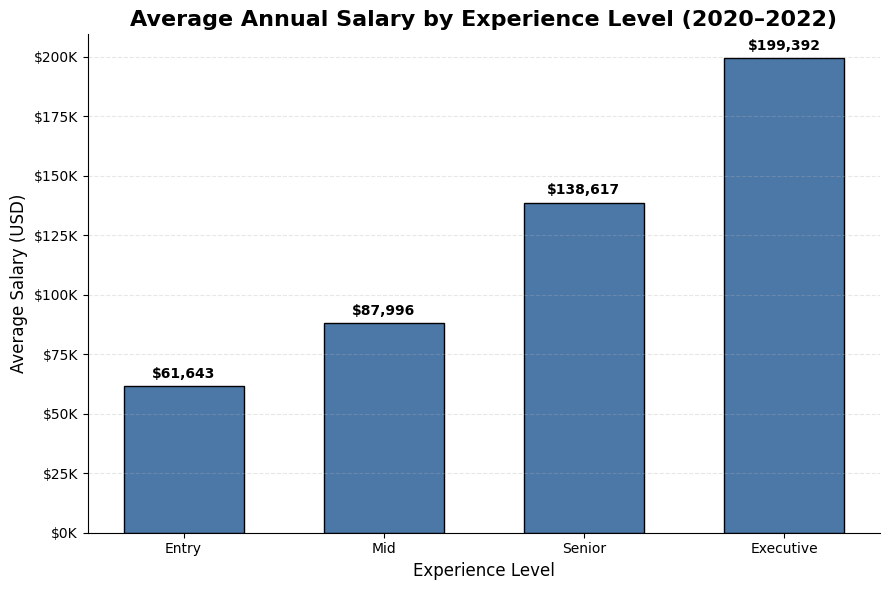

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

df.columns = df.columns.str.strip()

df["salary_in_usd"] = (
    df["salary_in_usd"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["salary_in_usd"] = pd.to_numeric(df["salary_in_usd"], errors="coerce")

experience_df = df.dropna(subset=["salary_in_usd"]).copy()

experience_map = {
    "EN": "Entry",
    "MI": "Mid",
    "SE": "Senior",
    "EX": "Executive"
}

experience_df["experience_level"] = (
    experience_df["experience_level"]
    .replace(experience_map)
)

order = ["Entry", "Mid", "Senior", "Executive"]


experience_salary = (
    experience_df
    .groupby("experience_level")["salary_in_usd"]
    .mean()
    .reindex(order)
)

experience_count = (
    experience_df
    .groupby("experience_level")
    .size()
    .reindex(order)
)

summary = pd.DataFrame({
    "Experience Level": order,
    "Average Salary (USD)": experience_salary.values,
    "Number of Records": experience_count.values
})

summary["Average Salary (USD)"] = summary["Average Salary (USD)"].map(lambda x: f"${x:,.0f}")

print(summary)

plt.figure(figsize=(9,6))

bars = plt.bar(
    order,
    experience_salary.values,
    color="#4C78A8",
    edgecolor="black",
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3500,
        f"${height:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

formatter = FuncFormatter(lambda x, pos: f"${x/1000:.0f}K")
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "Average Annual Salary by Experience Level (2020–2022)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Interpretation

The analysis shows a clear positive relationship between professional experience and average annual salary. Average compensation increases steadily from **USD 61,643** for **Entry-level** professionals to **USD 199,392** for **Executive-level** professionals.

The largest salary increase occurs between the **Mid-level** and **Senior-level** stages, suggesting that advancing into senior technical or leadership positions has a significant impact on earning potential.

The Senior-level salary estimate is based on the largest number of observations (**280 records**), making it the most reliable average in the dataset. Although Executive-level professionals earn the highest average salary, this estimate is based on only **26 records** and should therefore be interpreted with appropriate caution.

## Insight

Professional experience is one of the strongest factors influencing compensation in the data science industry.

For employers, attracting senior and executive talent requires substantially higher compensation packages compared to entry-level hiring. For professionals, the findings suggest that continuous skill development, technical expertise, and career progression into senior roles can significantly improve long-term earning potential.

These results also indicate that salary benchmarks for executive positions should be interpreted carefully due to the relatively small sample size available in the dataset.

# Analysis 2: Does Company Size Influence Salary?

Company size can affect compensation through factors such as available resources, organizational structure, and hiring budgets. This analysis compares the average annual salary across small, medium, and large companies to understand whether company size influences employee compensation.

  Company Size Average Salary (USD)  Number of Records
0        Small              $77,633                 83
1       Medium             $116,905                326
2        Large             $119,243                198


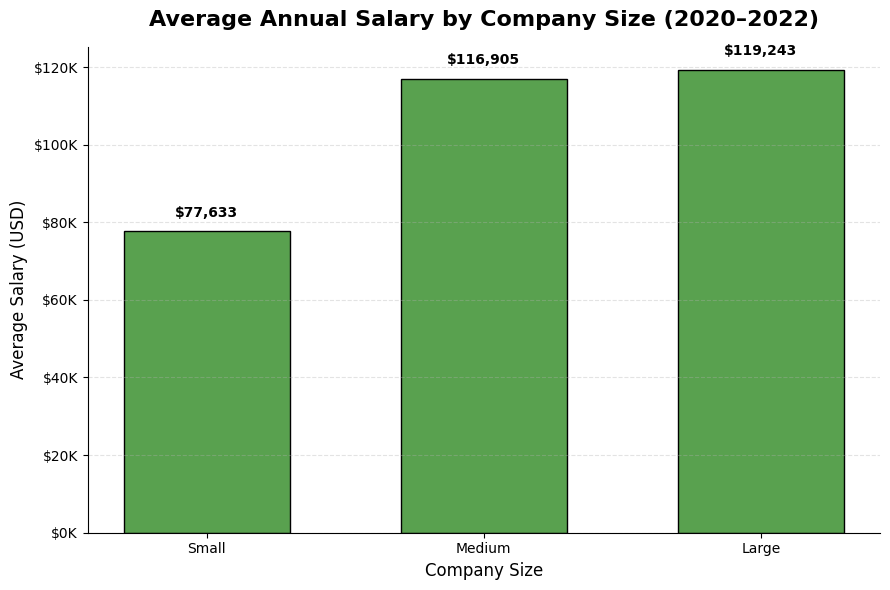

In [39]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


company_map = {
    "S": "Small",
    "M": "Medium",
    "L": "Large"
}

company_df = df.copy()

company_df["company_size"] = company_df["company_size"].replace(company_map)

order = ["Small", "Medium", "Large"]


company_salary = (
    company_df
    .groupby("company_size")["salary_in_usd"]
    .mean()
    .reindex(order)
)

company_count = (
    company_df
    .groupby("company_size")
    .size()
    .reindex(order)
)

summary = company_salary.to_frame(name="Average Salary (USD)")
summary["Number of Records"] = company_count

summary = summary.reset_index()

summary.columns = [
    "Company Size",
    "Average Salary (USD)",
    "Number of Records"
]

summary["Average Salary (USD)"] = (
    summary["Average Salary (USD)"]
    .map(lambda x: f"${x:,.0f}")
)

print(summary)


labels = ["Small", "Medium", "Large"]
values = company_salary.values

plt.figure(figsize=(9,6))

bars = plt.bar(
    labels,
    values,
    color="#59A14F",
    edgecolor="black",
    width=0.6
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3000,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

formatter = FuncFormatter(lambda x, pos: f"${x/1000:.0f}K")
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "Average Annual Salary by Company Size (2020–2022)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Company Size", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Interpretation

The analysis indicates that company size has a noticeable impact on average annual salary. Employees working in **Medium** and **Large** companies earn significantly higher average salaries than those in **Small** companies.

The average salary increases from **USD 77,633** in Small companies to **USD 116,905** in Medium companies, representing an increase of approximately **51%**. Salaries in Large companies average **USD 119,243**, which is only slightly higher (about **2%**) than Medium companies.

The Medium company category contains the largest number of observations (**326 records**), making its average salary the most reliable estimate. Although Large companies offer the highest average salary, the relatively small difference compared with Medium companies suggests that company size beyond the medium level may have only a limited effect on compensation.

## Insight

- Small companies have the lowest average annual salary (**USD 77,633**).
- Medium and Large companies offer substantially higher average salaries than Small companies.
- The salary difference between Medium and Large companies is relatively small (**approximately 2%**), indicating that compensation stabilizes once organizations reach a certain size.
- Since the Medium company category includes the largest number of observations (**326 records**), its average salary provides the strongest benchmark for comparison.


## Connection to Previous Analysis

While professional experience appears to be the strongest driver of salary, company size also influences compensation. However, the effect of company size is less pronounced than the impact of career progression observed in Analysis 1.

# Analysis 3: Does Remote Work Influence Salary?

The rise of remote work has changed hiring practices across the technology industry. This analysis examines whether employees working remotely receive different levels of compensation compared to those working in hybrid or on-site roles.

  Work Arrangement Average Salary (USD)  Number of Records
0          On-site             $106,355                127
1           Hybrid              $80,823                 99
2           Remote             $122,457                381


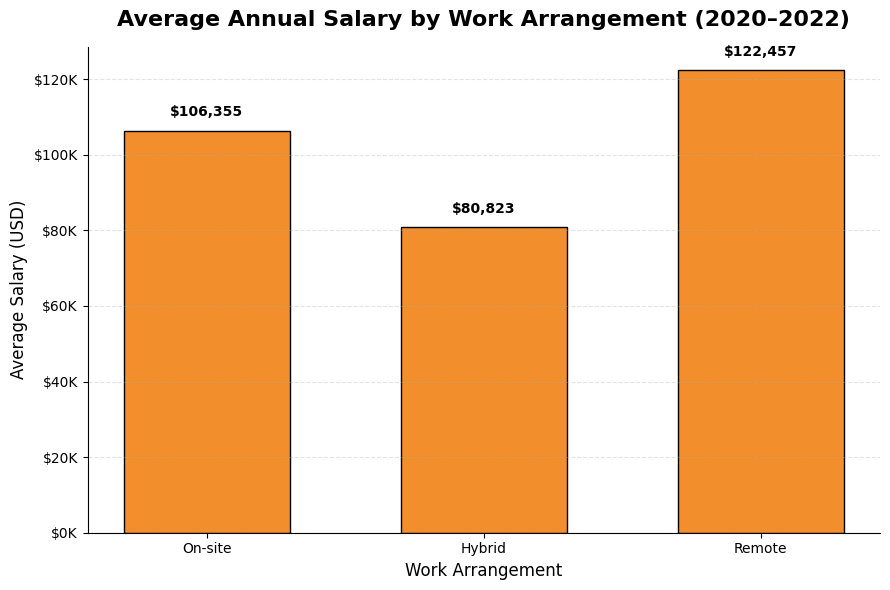

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

remote_map = {
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
}

remote_df = df.copy()

remote_df["remote_ratio"] = remote_df["remote_ratio"].replace(remote_map)

order = ["On-site", "Hybrid", "Remote"]

remote_salary = (
    remote_df
    .groupby("remote_ratio")["salary_in_usd"]
    .mean()
    .reindex(order)
)

remote_count = (
    remote_df
    .groupby("remote_ratio")
    .size()
    .reindex(order)
)

summary = remote_salary.to_frame(name="Average Salary (USD)")
summary["Number of Records"] = remote_count

summary = summary.reset_index()

summary.columns = [
    "Work Arrangement",
    "Average Salary (USD)",
    "Number of Records"
]

summary["Average Salary (USD)"] = (
    summary["Average Salary (USD)"]
    .map(lambda x: f"${x:,.0f}")
)

print(summary)

labels = ["On-site", "Hybrid", "Remote"]
values = remote_salary.values

plt.figure(figsize=(9,6))

bars = plt.bar(
    labels,
    values,
    color="#F28E2B",
    edgecolor="black",
    width=0.6
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3000,
        f"${height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

formatter = FuncFormatter(lambda x, pos: f"${x/1000:.0f}K")
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "Average Annual Salary by Work Arrangement (2020–2022)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Work Arrangement", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Interpretation

The analysis shows noticeable differences in average annual salary across work arrangements. **Remote** employees earn the highest average salary (**USD 122,457**), followed by **On-site** employees (**USD 106,355**), while **Hybrid** employees have the lowest average salary (**USD 80,823**).

Remote work is also the most common work arrangement in the dataset, representing **381 observations**, making its average salary the most reliable estimate. In contrast, the Hybrid category contains only **99 observations**, so its average should be interpreted with more caution.

These results suggest that employees in fully remote positions tend to receive higher compensation. However, this analysis does not establish that remote work itself causes higher salaries. Other factors, such as experience level, job role, company location, and employer characteristics, may also contribute to these differences.

## Insight

- Remote employees have the highest average annual salary (**USD 122,457**).
- On-site employees earn an average salary of **USD 106,355**, which is higher than Hybrid employees but lower than Remote employees.
- Hybrid employees have the lowest average salary (**USD 80,823**) among the three work arrangements.
- The Remote category contains the largest number of observations (**381 records**), making it the most representative group in the dataset.
- Salary differences across work arrangements may also be influenced by factors such as experience, job role, and company characteristics rather than work arrangement alone.

## Connection to Previous Analyses

The previous analyses showed that both **professional experience** and **company size** influence compensation. This analysis indicates that work arrangement is also associated with salary differences. However, the variation observed here is likely influenced by multiple factors, suggesting that compensation is determined by a combination of experience, employer characteristics, and workplace policies rather than a single variable.

# Analysis 4: Which Data Science Roles Offer the Highest Average Salaries?

Job titles often reflect different levels of technical expertise, specialization, and responsibility. This analysis identifies the highest-paying data science roles while considering the number of observations for each role to ensure meaningful comparisons.

                           Average_Salary  Number_of_Records
job_title                                                   
Principal Data Scientist         $215,242                  7
Director of Data Science         $195,074                  7
Data Architect                   $177,874                 11
Applied Data Scientist           $175,655                  5
Head of Data                     $160,163                  5
Machine Learning Scientist       $158,412                  8
Data Science Manager             $158,328                 12
Lead Data Engineer               $139,724                  6
Data Analytics Manager           $127,134                  7
Data Engineering Manager         $123,227                  5


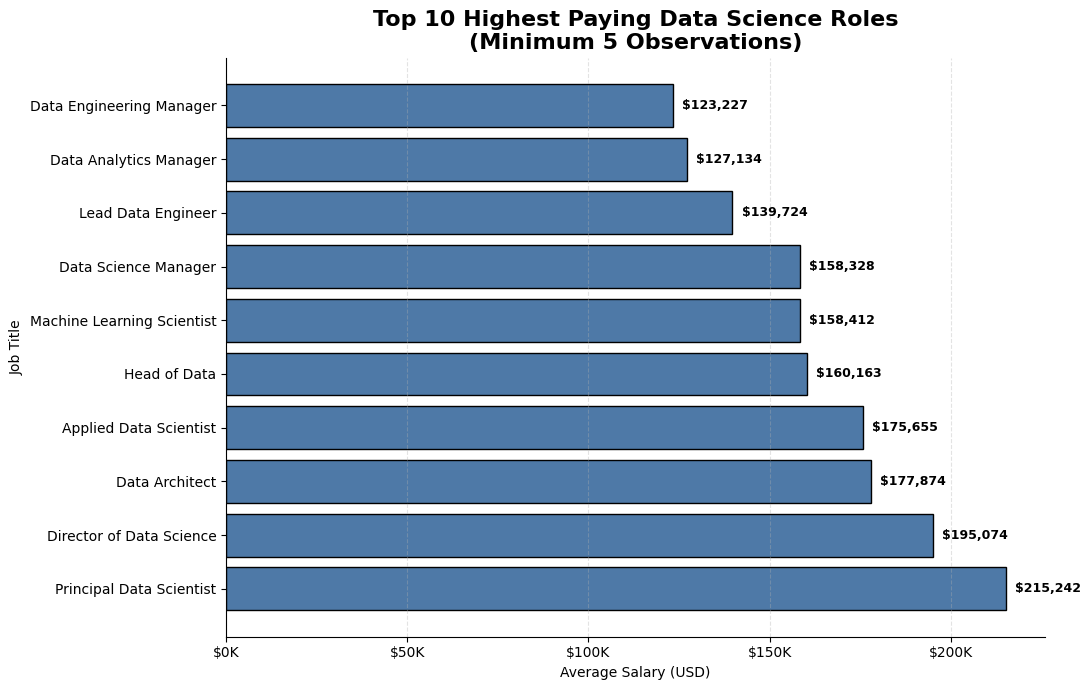

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

job_df = df.copy()

job_summary = (
    job_df
    .groupby("job_title")
    .agg(
        Average_Salary=("salary_in_usd", "mean"),
        Number_of_Records=("salary_in_usd", "count")
    )
)

job_summary = job_summary[
    job_summary["Number_of_Records"] >= 5
]


job_summary = (
    job_summary
    .sort_values("Average_Salary", ascending=False)
    .head(10)
)

display_table = job_summary.copy()

display_table["Average_Salary"] = (
    display_table["Average_Salary"]
    .map(lambda x: f"${x:,.0f}")
)

print(display_table)


plt.figure(figsize=(11,7))

bars = plt.barh(
    job_summary.index,
    job_summary["Average_Salary"],
    color="#4E79A7",
    edgecolor="black"
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 2500,
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

formatter = FuncFormatter(
    lambda x, pos: f"${x/1000:.0f}K"
)

plt.gca().xaxis.set_major_formatter(formatter)

plt.title(
    "Top 10 Highest Paying Data Science Roles\n(Minimum 5 Observations)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.grid(axis="x", linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

## Interpretation

The analysis highlights several specialized and leadership-oriented roles among the highest-paying positions in the data science industry. **Principal Data Scientist** has the highest average annual salary (**USD 215,242**), followed by **Director of Data Science** (**USD 195,074**) and **Data Architect** (**USD 177,874**).

Most of the highest-paying positions are senior leadership or highly specialized technical roles, indicating that advanced expertise and managerial responsibilities are associated with substantially higher compensation.

However, several of these job titles contain relatively small sample sizes (between **5 and 12 observations**). While these roles appear to offer the highest average salaries in this dataset, additional data would provide greater confidence in these estimates.

## Insights

- **Principal Data Scientist** has the highest average annual salary (**USD 215,242**) among job titles with at least five observations.
- Leadership and architecture-focused positions dominate the list of highest-paying roles, suggesting that technical specialization and management responsibilities contribute to higher compensation.
- All top ten roles have relatively small sample sizes (**5–12 observations**), so salary estimates should be interpreted as indicative rather than definitive.
- The results suggest that advancing into senior technical or leadership positions may offer greater salary growth than changing company size or work arrangement alone.

## Connection to Previous Analyses

The previous analyses demonstrated that professional experience, company size, and work arrangement are associated with salary differences. This analysis further shows that **job role** is another important factor influencing compensation.

Unlike the previous analyses, however, job titles have much smaller sample sizes, meaning these salary estimates should be interpreted more cautiously. Together, the findings suggest that salary is influenced by a combination of experience, organizational characteristics, work arrangement, and role specialization rather than a single factor.

# Analysis 5: How Have Data Science Salaries Changed Over Time?

The demand for data professionals has grown rapidly in recent years. This analysis examines how average annual salaries changed between **2020 and 2022** to understand compensation trends over time and whether the market experienced sustained salary growth.

   Year Average Salary (USD)  Number of Records
0  2020              $95,813                 72
1  2021              $99,854                217
2  2022             $124,522                318


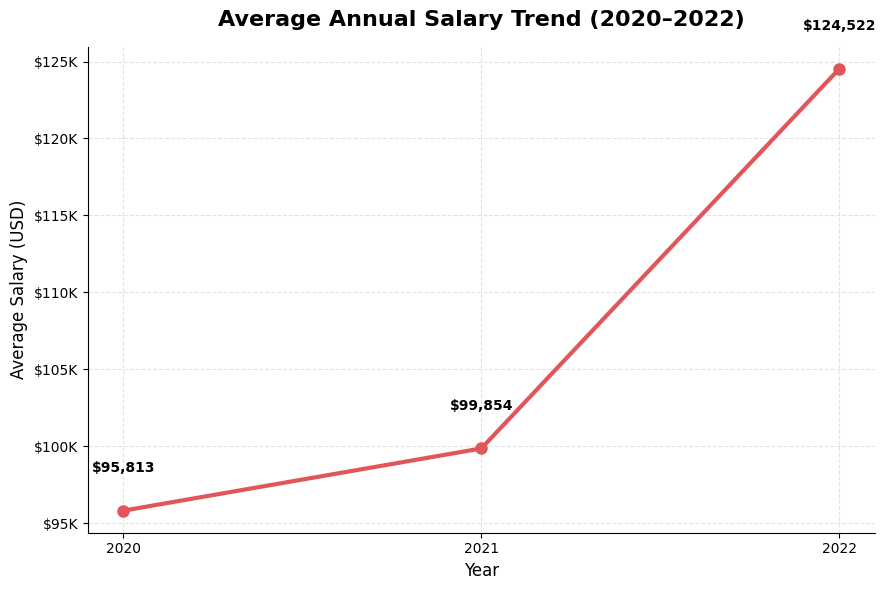

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


year_salary = (
    df
    .groupby("work_year")["salary_in_usd"]
    .mean()
)

year_count = (
    df
    .groupby("work_year")
    .size()
)

summary = year_salary.to_frame(name="Average Salary (USD)")
summary["Number of Records"] = year_count

summary = summary.reset_index()

summary.columns = [
    "Year",
    "Average Salary (USD)",
    "Number of Records"
]

summary["Average Salary (USD)"] = (
    summary["Average Salary (USD)"]
    .map(lambda x: f"${x:,.0f}")
)

print(summary)


labels = summary["Year"].astype(str)
values = year_salary.values

plt.figure(figsize=(9,6))

plt.plot(
    labels,
    values,
    marker="o",
    linewidth=3,
    markersize=8,
    color="#E15759"
)

for x, y in zip(labels, values):
    plt.text(
        x,
        y + 2500,
        f"${y:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

formatter = FuncFormatter(lambda x, pos: f"${x/1000:.0f}K")
plt.gca().yaxis.set_major_formatter(formatter)

plt.title(
    "Average Annual Salary Trend (2020–2022)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

## Interpretation

The analysis shows that average annual salaries increased throughout the observed period from **2020 to 2022**. Average compensation rose from **USD 95,813** in **2020** to **USD 99,854** in **2021**, before increasing more substantially to **USD 124,522** in **2022**.

The most significant increase occurred between **2021 and 2022**, where the average salary increased by approximately **25%**. Overall, average compensation increased by nearly **30%** between **2020 and 2022**, indicating a strong rise in salaries during the period covered by the dataset.

The number of observations also increased each year (**72** in 2020, **217** in 2021, and **318** in 2022). As a result, the 2022 salary estimate is based on the largest sample and is likely the most representative of the three years.

## Insights

- Average annual salaries increased from **USD 95,813** in **2020** to **USD 124,522** in **2022**.
- The largest year-over-year increase occurred between **2021** and **2022**, with average salaries rising by approximately **25%**.
- The dataset contains progressively more observations each year, making the **2022** salary estimate the most reliable.
- The results suggest that compensation for data science professionals increased considerably during the period covered by the dataset.

## Connection to Previous Analyses

The previous analyses showed that salary varies according to **professional experience**, **company size**, **work arrangement**, and **job role**. This analysis adds a time dimension, showing that average salaries also increased across the three-year period.

Together, these findings suggest that compensation in the data science industry is influenced by multiple factors, including individual career progression, organizational characteristics, role specialization, and broader market trends.

# Machine Learning: Predicting Annual Salary

After identifying the factors associated with salary through exploratory data analysis, the next step is to develop a predictive model.

The objective is to predict an employee's annual salary (USD) based on job-related characteristics such as experience level, employment type, job title, company size, work arrangement, company location, employee residence, and work year.

This model demonstrates how machine learning can support salary estimation and identify the variables that contribute most to compensation.

## Step 1: Feature Selection and Data Preprocessing

The target variable for this model is **salary_in_usd**, which represents the employee's annual salary in U.S. dollars.

The following job-related features are used as predictors:

- Work Year
- Experience Level
- Employment Type
- Job Title
- Employee Residence
- Remote Ratio
- Company Location
- Company Size

Columns such as **salary** and **salary_currency** are excluded because they contain information directly related to the target variable and would introduce data leakage.

In [43]:
from sklearn.preprocessing import LabelEncoder

features = [
    "work_year",
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size"
]

X = df[features].copy()
y = df["salary_in_usd"]

label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col])
    label_encoders[col] = encoder

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFirst Five Rows of Features:")
print(X.head())

Feature Matrix Shape: (607, 8)
Target Shape: (607,)

First Five Rows of Features:
   work_year  experience_level  employment_type  job_title  \
0       2020                 2                2         22   
1       2020                 3                2         41   
2       2020                 3                2          7   
3       2020                 2                2         47   
4       2020                 3                2         38   

   employee_residence  remote_ratio  company_location  company_size  
0                  14             0                12             0  
1                  32             0                29             2  
2                  20            50                18             1  
3                  23             0                20             2  
4                  55            50                48             0  


## Step 2: Train-Test Split

The dataset is divided into training and testing subsets.

- **80%** of the data is used to train the model.
- **20%** is reserved for testing to evaluate how well the model performs on unseen data.

In [44]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (485, 8)
Testing Features  : (122, 8)
Training Target   : (485,)
Testing Target    : (122,)


## Step 3: Model Training

A **Random Forest Regressor** is used to predict annual salaries.

Random Forest is an ensemble learning algorithm that combines predictions from multiple decision trees, improving prediction accuracy while reducing overfitting.

It is well suited for datasets containing both numerical and categorical features after encoding.

In [45]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


## Step 4: Model Evaluation

After training the model, its performance is evaluated using the testing dataset.

The following evaluation metrics are used:

- **Mean Absolute Error (MAE):** Measures the average prediction error.
- **Root Mean Squared Error (RMSE):** Penalizes larger prediction errors more heavily.
- **R² Score:** Measures how well the model explains the variation in salary. A value closer to 1 indicates better predictive performance.

In [46]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-" * 40)
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.3f}")

Model Performance
----------------------------------------
Mean Absolute Error (MAE): $27,712.74
Root Mean Squared Error (RMSE): $41,319.21
R² Score: 0.555


## Step 5: Actual vs Predicted Salaries

The scatter plot compares the model's predicted salaries with the actual salaries from the testing dataset.

If predictions are accurate, the points should lie close to the diagonal reference line.

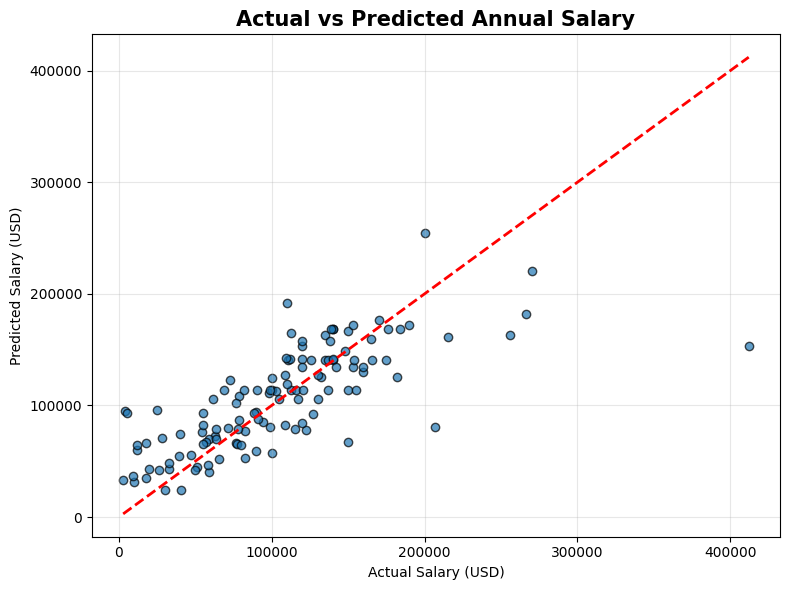

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7,
    edgecolors="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Annual Salary",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Feature Importance

Random Forest models estimate the relative importance of each input feature.

This analysis identifies which job characteristics contribute most to salary prediction and allows comparison with the patterns observed during exploratory data analysis.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print(feature_importance)

              Feature  Importance
4  employee_residence    0.373601
3           job_title    0.308796
1    experience_level    0.144678
0           work_year    0.052196
7        company_size    0.051736
5        remote_ratio    0.033645
6    company_location    0.027712
2     employment_type    0.007636


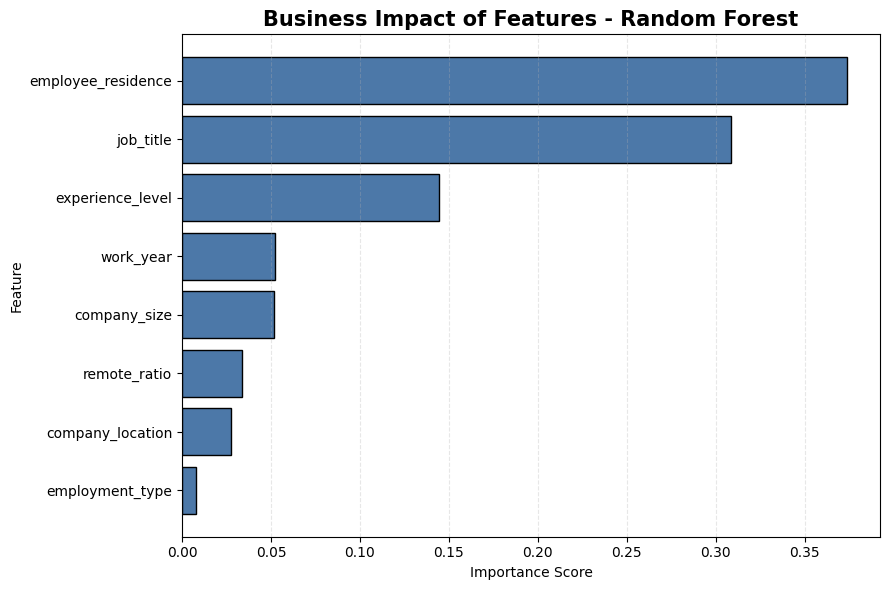

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    color="#4C78A8",
    edgecolor="black"
)

plt.title(
    "Business Impact of Features - Random Forest",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Model Interpretation

The Random Forest model achieved an **R² score of 0.554**, indicating that it explains approximately **55.4%** of the variation in annual salaries. This suggests that the model captures many of the key factors influencing salary while also indicating that additional variables not included in the dataset contribute to compensation.

The model achieved a **Mean Absolute Error (MAE)** of **USD 27,728**, meaning that predicted salaries differ from actual salaries by approximately **USD 27.7K** on average. The **Root Mean Squared Error (RMSE)** of **USD 41,330** indicates that larger prediction errors occur for some observations, particularly among the highest salary values.

Feature importance analysis identified **Employee Residence**, **Job Title**, and **Experience Level** as the three most influential predictors of salary. These findings support the exploratory analysis by confirming that compensation is influenced by a combination of geographic location, professional role, and career progression rather than a single factor.


## Key Insights

* The Random Forest model explained approximately **55%** of the variation in annual salaries (**R² = 0.554**).
* The average prediction error (**MAE**) was approximately **USD 27.7K**.
* **Employee Residence** was the most influential predictor of salary, followed by **Job Title** and **Experience Level**.
* Prediction accuracy was strongest for low- and mid-range salaries, while higher salaries showed larger prediction errors.
* The machine learning results reinforce the exploratory analysis by demonstrating that salary is determined by multiple interacting factors rather than a single characteristic.


# Overall Business Insights

The analysis identified several factors associated with salary differences in the data science industry.

The most important findings include:

- Professional experience is strongly associated with higher salaries, with Executive-level professionals earning over three times the average salary of Entry-level professionals.
- Medium and Large companies generally offer higher compensation than Small companies.
- Remote employees earned the highest average salaries in this dataset, although this relationship may also reflect differences in experience, job roles, and geographic location.
- Leadership and specialized technical roles, such as Principal Data Scientist and Director of Data Science, received the highest average salaries.
- Average salaries increased substantially between 2020 and 2022, reflecting continued growth in demand for data professionals.
- The predictive model confirmed that Employee Residence, Job Title, and Experience Level are the strongest predictors of salary.

# Business Recommendations

Based on the analysis, the following recommendations are suggested:

- Organizations should offer competitive compensation packages when recruiting experienced and specialized data professionals.
- Companies should regularly benchmark salaries against current market trends to remain competitive.
- Professionals seeking higher salaries should focus on developing advanced technical skills, leadership experience, and expertise in specialized roles.
- Organizations hiring internationally should account for regional salary differences when designing compensation strategies.

# Project Limitations

Although this project provides valuable insights, several limitations should be considered:

- The dataset contains only 607 observations and may not represent the entire global data science job market.
- Several job titles have relatively small sample sizes, reducing confidence in some average salary estimates.
- The predictive model achieved moderate performance (R² = 0.554), indicating that additional variables not included in the dataset also influence salary.
- Important factors such as education, years of professional experience, technical skills, company revenue, bonuses, and stock compensation were not available.

# Future Work

Future improvements could include:

- Expanding the dataset with additional years and more observations.
- Incorporating variables such as education level, technical skills, and industry sector.
- Comparing multiple machine learning algorithms to improve prediction accuracy.
- Developing an interactive dashboard using Streamlit or Power BI for business users.

# Project Summary

This project performed an end-to-end analysis of the Data Science Salaries dataset using Python.

The workflow included data inspection, data cleaning, exploratory data analysis, predictive modeling, and business interpretation.

Five business questions were investigated to understand how professional experience, company size, work arrangement, job role, and time influence salary.

A Random Forest Regression model was then developed to predict annual salaries, achieving an R² score of 0.554. Feature importance analysis identified Employee Residence, Job Title, and Experience Level as the strongest predictors of salary.

Overall, the project demonstrates the complete data science workflow—from raw data to actionable business insights—and highlights how analytics and machine learning can support evidence-based decision-making.